In [1]:
import os

DATASET_PATH = "/kaggle/input/mandeley-dataset-dr"

print("📊 Class-wise file count:\n")

for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    if os.path.isdir(cls_path):
        num_files = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        print(f"{cls:20s} -> {num_files}")


📊 Class-wise file count:

Mild                 -> 370
Moderate             -> 999
No_DR                -> 1805
Proliferate_DR       -> 295
Severe               -> 193


In [2]:
import os

# Kaggle dataset path (already extracted)
DATASET_PATH = "/kaggle/input/mandeley-dataset-dr"

image_exts = ('.jpg', '.jpeg', '.png')

total_images = 0
total_size = 0
class_counts = {}

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)

    if not os.path.isdir(cls_path):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(image_exts)
    ]

    class_counts[cls] = len(images)
    total_images += len(images)

    for img in images:
        total_size += os.path.getsize(os.path.join(cls_path, img))

print("📦 Total Images:", total_images)
print("💾 Total Dataset Size: {:.2f} MB".format(total_size / (1024 * 1024)))

print("\n📊 Class-wise Counts:")
print("-" * 30)
for cls, count in sorted(class_counts.items()):
    print(f"{cls:20s}: {count}")


📦 Total Images: 3662
💾 Total Dataset Size: 238.64 MB

📊 Class-wise Counts:
------------------------------
Mild                : 370
Moderate            : 999
No_DR               : 1805
Proliferate_DR      : 295
Severe              : 193


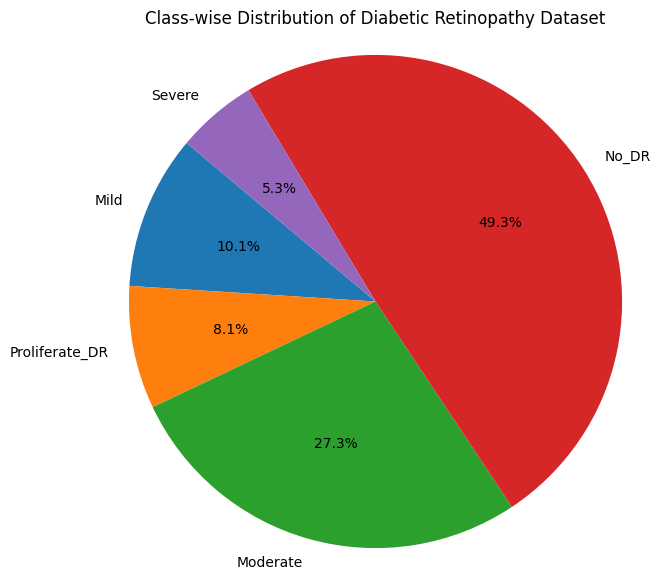

In [3]:
import matplotlib.pyplot as plt

labels = class_counts.keys()
sizes = class_counts.values()

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title("Class-wise Distribution of Diabetic Retinopathy Dataset")
plt.axis('equal')
plt.show()


In [4]:
#Step 1: Remove corrupted / unreadable / blank images
import os
import cv2
from PIL import Image
import numpy as np

dataset_path = "/kaggle/input/mandeley-dataset-dr"
image_exts = ('.jpg', '.jpeg', '.png')

removed_images = 0
checked_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_exts):
            img_path = os.path.join(root, file)
            checked_images += 1

            try:
                # Check if image is readable (PIL)
                with Image.open(img_path) as img:
                    img.verify()

                # Check if image is blank (OpenCV)
                img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_cv is None or np.mean(img_cv) < 5:
                    os.remove(img_path)
                    removed_images += 1

            except Exception:
                # Corrupted or unreadable image
                os.remove(img_path)
                removed_images += 1

print("Checked images:", checked_images)
print("Removed corrupted/blank images:", removed_images)


Checked images: 3662
Removed corrupted/blank images: 0


In [6]:
import shutil
import os

SRC_PATH = "/kaggle/input/mandeley-dataset-dr"
DST_PATH = "/kaggle/working/mandeley-dataset-dr"

if not os.path.exists(DST_PATH):
    shutil.copytree(SRC_PATH, DST_PATH)
    print("✅ Dataset copied to writable directory")
else:
    print("ℹ️ Dataset already copied")


✅ Dataset copied to writable directory


In [7]:
import os
import cv2
import hashlib

dataset_path = "/kaggle/working/mandeley-dataset-dr"
image_exts = ('.jpg', '.jpeg', '.png')

hashes = {}
duplicate_count = 0
checked_images = 0

def get_image_hash(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img = cv2.resize(img, (256, 256))
    return hashlib.md5(img.tobytes()).hexdigest()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(image_exts):
            img_path = os.path.join(root, file)
            checked_images += 1

            img_hash = get_image_hash(img_path)
            if img_hash is None:
                continue

            if img_hash in hashes:
                os.remove(img_path)     # ✅ now allowed
                duplicate_count += 1
            else:
                hashes[img_hash] = img_path

print("Checked images:", checked_images)
print("Duplicate images removed:", duplicate_count)


Checked images: 3662
Duplicate images removed: 128


In [8]:
import os

DATASET_PATH = "/kaggle/working/mandeley-dataset-dr"
image_exts = ('.jpg', '.jpeg', '.png')

class_counts = {}

for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(image_exts)
    ]
    class_counts[cls] = len(images)

print(class_counts)


{'Mild': 338, 'Moderate': 927, 'No_DR': 1800, 'Proliferate_DR': 283, 'Severe': 186}


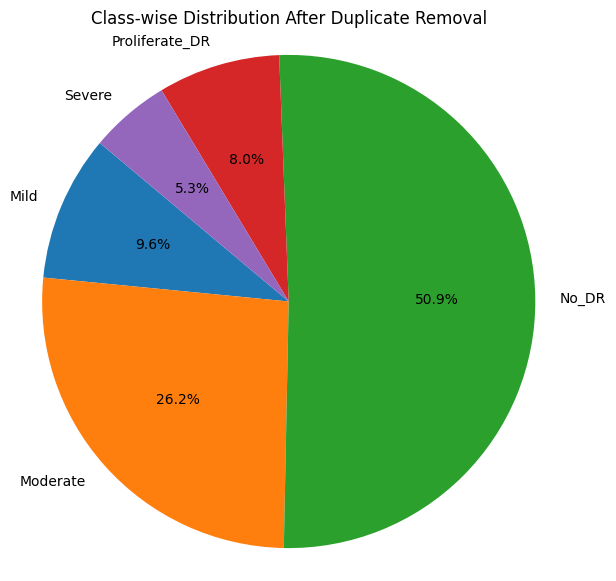

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.pie(
    class_counts.values(),
    labels=class_counts.keys(),
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Class-wise Distribution After Duplicate Removal")
plt.axis('equal')  # makes pie circular
plt.show()


In [10]:
import os

# Kaggle writable dataset path
dataset_path = "/kaggle/working/mandeley-dataset-dr"

expected_classes = {
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative"
}

found_classes = set()

for item in os.listdir(dataset_path):
    path = os.path.join(dataset_path, item)
    if os.path.isdir(path):
        found_classes.add(item)

print("Expected classes:", expected_classes)
print("Found classes:", found_classes)

missing = expected_classes - found_classes
extra = found_classes - expected_classes

if missing:
    print("❌ Missing class folders:", missing)
if extra:
    print("⚠️ Unexpected class folders:", extra)

if not missing and not extra:
    print("✅ Folder names are consistent")


Expected classes: {'No_DR', 'Severe', 'Proliferative', 'Mild', 'Moderate'}
Found classes: {'Proliferate_DR', 'Moderate', 'No_DR', 'Severe', 'Mild'}
❌ Missing class folders: {'Proliferative'}
⚠️ Unexpected class folders: {'Proliferate_DR'}


In [11]:
label_map = {
    "0": "No_DR",
    "1": "Mild",
    "2": "Moderate",
    "3": "Severe",
    "4": "Proliferative"
}

for old, new in label_map.items():
    old_path = os.path.join(dataset_path, old)
    new_path = os.path.join(dataset_path, new)

    if os.path.exists(old_path):
        os.rename(old_path, new_path)
        print(f"Renamed {old} → {new}")


In [12]:
# ===============================
# Resize DR Dataset (Kaggle)
# ===============================

import os
import cv2

# -------- PATHS (KAGGLE) --------
INPUT_DIR = "/kaggle/input/mandeley-dataset-dr"
OUTPUT_DIR = "/kaggle/working/mendeley_dataset_224"

IMAGE_SIZE = (224, 224)
IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

# -------- CREATE OUTPUT FOLDERS --------
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = [
    d for d in os.listdir(INPUT_DIR)
    if os.path.isdir(os.path.join(INPUT_DIR, d))
]

for cls in classes:
    os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)

# -------- RESIZE PROCESS --------
resized_count = 0
skipped_count = 0

for cls in classes:
    input_cls_path = os.path.join(INPUT_DIR, cls)
    output_cls_path = os.path.join(OUTPUT_DIR, cls)

    for file in os.listdir(input_cls_path):
        if not file.lower().endswith(IMAGE_EXTS):
            continue

        in_path = os.path.join(input_cls_path, file)
        out_path = os.path.join(output_cls_path, file)

        img = cv2.imread(in_path)
        if img is None:
            skipped_count += 1
            continue

        img_resized = cv2.resize(
            img, IMAGE_SIZE, interpolation=cv2.INTER_AREA
        )
        cv2.imwrite(out_path, img_resized)
        resized_count += 1

# -------- SUMMARY --------
print("✅ RESIZING COMPLETED")
print("📂 Input Dataset :", INPUT_DIR)
print("📁 Output Dataset:", OUTPUT_DIR)
print("🖼️ Images Resized:", resized_count)
print("⚠️ Images Skipped:", skipped_count)

# -------- QUICK VERIFICATION --------
sample_class = classes[0]
sample_images = os.listdir(os.path.join(OUTPUT_DIR, sample_class))

if sample_images:
    sample_path = os.path.join(OUTPUT_DIR, sample_class, sample_images[0])
    sample = cv2.imread(sample_path)
    print("🔍 Sample image shape:", sample.shape)
else:
    print("⚠️ No images found in sample class")


✅ RESIZING COMPLETED
📂 Input Dataset : /kaggle/input/mandeley-dataset-dr
📁 Output Dataset: /kaggle/working/mendeley_dataset_224
🖼️ Images Resized: 3662
⚠️ Images Skipped: 0
🔍 Sample image shape: (224, 224, 3)


In [13]:
# ==========================================
# Normalize Images to [0,1] (Kaggle)
# ==========================================

import os
import cv2
import numpy as np

# -------- PATHS (KAGGLE) --------
INPUT_DIR = "/kaggle/working/mendeley_dataset_224"
OUTPUT_DIR = "/kaggle/working/mendeley_dataset_224_norm"

IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

# -------- CREATE OUTPUT STRUCTURE --------
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = [
    d for d in os.listdir(INPUT_DIR)
    if os.path.isdir(os.path.join(INPUT_DIR, d))
]

for cls in classes:
    os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)

# -------- NORMALIZATION --------
normalized = 0
skipped = 0

for cls in classes:
    in_cls = os.path.join(INPUT_DIR, cls)
    out_cls = os.path.join(OUTPUT_DIR, cls)

    for file in os.listdir(in_cls):
        if not file.lower().endswith(IMAGE_EXTS):
            continue

        in_path = os.path.join(in_cls, file)
        out_path = os.path.join(out_cls, file)

        img = cv2.imread(in_path)
        if img is None:
            skipped += 1
            continue

        # Normalize to [0,1] in memory
        img_norm = img.astype(np.float32) / 255.0

        # Save back as uint8 (standard practice for storage)
        cv2.imwrite(out_path, (img_norm * 255).astype(np.uint8))
        normalized += 1

# -------- SUMMARY --------
print("✅ NORMALIZATION COMPLETED")
print("📂 Input Dataset :", INPUT_DIR)
print("📁 Output Dataset:", OUTPUT_DIR)
print("🖼️ Images Normalized:", normalized)
print("⚠️ Images Skipped:", skipped)

# -------- QUICK CHECK --------
sample_class = classes[0]
sample_images = os.listdir(os.path.join(OUTPUT_DIR, sample_class))

if sample_images:
    sample_path = os.path.join(OUTPUT_DIR, sample_class, sample_images[0])
    sample = cv2.imread(sample_path)
    print(
        "🔍 Sample pixel range:",
        sample.min() / 255.0,
        "to",
        sample.max() / 255.0
    )
else:
    print("⚠️ No images found for verification")


✅ NORMALIZATION COMPLETED
📂 Input Dataset : /kaggle/working/mendeley_dataset_224
📁 Output Dataset: /kaggle/working/mendeley_dataset_224_norm
🖼️ Images Normalized: 3662
⚠️ Images Skipped: 0
🔍 Sample pixel range: 0.0 to 1.0


In [14]:
# ==========================================
# Retina Cropping ONLY (Kaggle)
# No Resize, No Normalize
# ==========================================

import os
import cv2

# -------- PATHS (KAGGLE) --------
INPUT_DIR = "/kaggle/working/mendeley_dataset_224_norm"
OUTPUT_DIR = "/kaggle/working/mendeley_dataset_224_norm_cropped"

IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -------- RETINA CROPPING FUNCTION --------
def crop_retina(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Binary threshold to separate retina from background
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return img  # fallback safety

    # Largest contour assumed retina
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # Add margin to avoid cutting edges
    margin = int(0.05 * max(w, h))
    x = max(0, x - margin)
    y = max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)

    return img[y:y+h, x:x+w]

# -------- PROCESS DATASET --------
classes = [
    d for d in os.listdir(INPUT_DIR)
    if os.path.isdir(os.path.join(INPUT_DIR, d))
]

for cls in classes:
    os.makedirs(os.path.join(OUTPUT_DIR, cls), exist_ok=True)

processed = 0
skipped = 0

for cls in classes:
    in_cls = os.path.join(INPUT_DIR, cls)
    out_cls = os.path.join(OUTPUT_DIR, cls)

    images = [
        f for f in os.listdir(in_cls)
        if f.lower().endswith(IMAGE_EXTS)
    ]

    if not images:
        print(f"⚠️ No images found in class: {cls}")
        continue

    for file in images:
        in_path = os.path.join(in_cls, file)
        out_path = os.path.join(out_cls, file)

        img = cv2.imread(in_path)
        if img is None:
            skipped += 1
            continue

        # Retina crop ONLY
        img_cropped = crop_retina(img)

        # Save without resizing or renormalizing
        cv2.imwrite(out_path, img_cropped)
        processed += 1

# -------- SUMMARY --------
print("✅ RETINA CROPPING COMPLETED (ONLY)")
print("📂 Input Dataset :", INPUT_DIR)
print("📁 Output Dataset:", OUTPUT_DIR)
print("🖼️ Images Cropped:", processed)
print("⚠️ Images Skipped:", skipped)

# -------- QUICK CHECK --------
sample_class = classes[0]
sample_images = os.listdir(os.path.join(OUTPUT_DIR, sample_class))

if sample_images:
    sample_path = os.path.join(OUTPUT_DIR, sample_class, sample_images[0])
    sample = cv2.imread(sample_path)
    print("🔍 Sample image shape after cropping:", sample.shape)
else:
    print("⚠️ No sample image available for verification")


✅ RETINA CROPPING COMPLETED (ONLY)
📂 Input Dataset : /kaggle/working/mendeley_dataset_224_norm
📁 Output Dataset: /kaggle/working/mendeley_dataset_224_norm_cropped
🖼️ Images Cropped: 3662
⚠️ Images Skipped: 0
🔍 Sample image shape after cropping: (224, 224, 3)


In [15]:
import os

# Kaggle writable dataset path
DATASET_DIR = "/kaggle/working/mendeley_dataset_224_norm_cropped"
IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

class_counts = {}

for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    count = sum(
        1 for f in os.listdir(cls_path)
        if f.lower().endswith(IMAGE_EXTS)
    )

    class_counts[cls] = count

print("📊 Class-wise Image Count:")
print("-" * 35)
for cls, count in sorted(class_counts.items()):
    print(f"{cls:15s}: {count}")

print("-" * 35)
print("Total Images:", sum(class_counts.values()))


📊 Class-wise Image Count:
-----------------------------------
Mild           : 370
Moderate       : 999
No_DR          : 1805
Proliferate_DR : 295
Severe         : 193
-----------------------------------
Total Images: 3662


In [16]:
# =========================
# DATASET BALANCING VIA AUGMENTATION (KAGGLE)
# =========================

import os
import cv2
from tqdm import tqdm
import albumentations as A

# -------- DATASET PATH (KAGGLE) --------
DATASET_DIR = "/kaggle/working/mendeley_dataset_224_norm_cropped"
IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

# -------------------------
# Medically safe augmentations for Diabetic Retinopathy
# -------------------------
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.5
    ),
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),
])

# -------------------------
# Count images per class
# -------------------------
class_counts = {}

for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(IMAGE_EXTS)
    ]
    class_counts[cls] = len(images)

max_count = max(class_counts.values())
print("🎯 Target images per class:", max_count)

# -------------------------
# Augment minority classes
# -------------------------
for cls, count in class_counts.items():
    cls_path = os.path.join(DATASET_DIR, cls)

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(IMAGE_EXTS)
    ]

    if len(images) == 0:
        print(f"⚠️ Skipping empty class: {cls}")
        continue

    needed = max_count - count
    if needed <= 0:
        continue

    print(f"🔄 Augmenting '{cls}' → generating {needed} images")

    for i in tqdm(range(needed)):
        img_name = images[i % len(images)]
        img_path = os.path.join(cls_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = augmenter(image=img)["image"]

        save_name = f"aug_{i}_{img_name}"
        save_path = os.path.join(cls_path, save_name)

        cv2.imwrite(
            save_path,
            cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
        )

print("✅ Dataset balancing completed successfully!")


/tmp/ipykernel_55/1059081280.py:25: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),


🎯 Target images per class: 1805
🔄 Augmenting 'Proliferate_DR' → generating 1510 images


100%|██████████| 1510/1510 [00:07<00:00, 194.11it/s]


🔄 Augmenting 'Severe' → generating 1612 images


100%|██████████| 1612/1612 [00:08<00:00, 199.06it/s]


🔄 Augmenting 'Moderate' → generating 806 images


100%|██████████| 806/806 [00:04<00:00, 196.14it/s]


🔄 Augmenting 'Mild' → generating 1435 images


100%|██████████| 1435/1435 [00:07<00:00, 195.27it/s]

✅ Dataset balancing completed successfully!


In [17]:
import os
import shutil
from sklearn.model_selection import train_test_split

# -------- PATHS (KAGGLE) --------
DATASET_DIR = "/kaggle/working/mendeley_dataset_224_norm_cropped"
BASE_DIR = "/kaggle/working/DR_split"

IMAGE_EXTS = ('.jpg', '.jpeg', '.png')

# -------- CREATE SPLIT DIRECTORIES --------
os.makedirs(BASE_DIR, exist_ok=True)

splits = ['train', 'val', 'test']
for s in splits:
    os.makedirs(os.path.join(BASE_DIR, s), exist_ok=True)

# -------- SPLIT DATASET --------
for cls in os.listdir(DATASET_DIR):
    cls_path = os.path.join(DATASET_DIR, cls)

    if not os.path.isdir(cls_path):
        continue

    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(IMAGE_EXTS)
    ]

    if len(images) == 0:
        print(f"⚠️ Skipping empty class: {cls}")
        continue

    # 70% train, 30% temp
    train_imgs, temp_imgs = train_test_split(
        images,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    # 15% val, 15% test
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    for split, data in zip(splits, [train_imgs, val_imgs, test_imgs]):
        split_path = os.path.join(BASE_DIR, split, cls)
        os.makedirs(split_path, exist_ok=True)

        for img in data:
            shutil.copy(
                os.path.join(cls_path, img),
                os.path.join(split_path, img)
            )

    print(f"✅ {cls}: "
          f"train={len(train_imgs)}, "
          f"val={len(val_imgs)}, "
          f"test={len(test_imgs)}")

print("🎉 Dataset split completed successfully!")


✅ No_DR: train=1263, val=271, test=271
✅ Proliferate_DR: train=1263, val=271, test=271
✅ Severe: train=1263, val=271, test=271
✅ Moderate: train=1263, val=271, test=271
✅ Mild: train=1263, val=271, test=271
🎉 Dataset split completed successfully!


In [18]:
!pip install -q timm torch torchvision scikit-learn


In [19]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DATA_DIR = "/kaggle/working/DR_split"

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 5

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tfms)
val_ds   = datasets.ImageFolder(f"{DATA_DIR}/val", transform=val_tfms)
test_ds  = datasets.ImageFolder(f"{DATA_DIR}/test", transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("Classes:", train_ds.classes)


Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']


In [20]:
import timm
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)
print("Using device:", device)


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Using device: cuda


In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


In [24]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == y).sum().item()

    acc = correct / len(loader.dataset)
    return total_loss, acc


def evaluate(model, loader):
    model.eval()
    correct = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            correct += (outputs.argmax(1) == y).sum().item()

    return correct / len(loader.dataset)


In [26]:
EPOCHS = 30

for epoch in range(EPOCHS):
    loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")


Epoch 01 | Train Acc: 0.4011 | Val Acc: 0.4266
Epoch 02 | Train Acc: 0.5197 | Val Acc: 0.5683
Epoch 03 | Train Acc: 0.5688 | Val Acc: 0.5852
Epoch 04 | Train Acc: 0.6234 | Val Acc: 0.6244
Epoch 05 | Train Acc: 0.6485 | Val Acc: 0.6539
Epoch 06 | Train Acc: 0.6747 | Val Acc: 0.6908
Epoch 07 | Train Acc: 0.6922 | Val Acc: 0.7151
Epoch 08 | Train Acc: 0.7268 | Val Acc: 0.7166
Epoch 09 | Train Acc: 0.7572 | Val Acc: 0.6827
Epoch 10 | Train Acc: 0.7769 | Val Acc: 0.7631
Epoch 11 | Train Acc: 0.7919 | Val Acc: 0.8007
Epoch 12 | Train Acc: 0.8226 | Val Acc: 0.7830
Epoch 13 | Train Acc: 0.8310 | Val Acc: 0.8007
Epoch 14 | Train Acc: 0.8356 | Val Acc: 0.7978
Epoch 15 | Train Acc: 0.8545 | Val Acc: 0.7985
Epoch 16 | Train Acc: 0.8613 | Val Acc: 0.8273
Epoch 17 | Train Acc: 0.8694 | Val Acc: 0.8251
Epoch 18 | Train Acc: 0.8854 | Val Acc: 0.8251
Epoch 19 | Train Acc: 0.8961 | Val Acc: 0.8199
Epoch 20 | Train Acc: 0.8896 | Val Acc: 0.8554
Epoch 21 | Train Acc: 0.9082 | Val Acc: 0.8236
Epoch 22 | Tr

In [27]:
optimizer = optim.AdamW(model.parameters(), lr=1e-5)

for epoch in range(30):
    loss, train_acc = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"[FT] Epoch {epoch+1:02d} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")


[FT] Epoch 01 | Train Acc: 0.9658 | Val Acc: 0.9041
[FT] Epoch 02 | Train Acc: 0.9759 | Val Acc: 0.9144
[FT] Epoch 03 | Train Acc: 0.9821 | Val Acc: 0.9122
[FT] Epoch 04 | Train Acc: 0.9835 | Val Acc: 0.9077
[FT] Epoch 05 | Train Acc: 0.9826 | Val Acc: 0.9033
[FT] Epoch 06 | Train Acc: 0.9846 | Val Acc: 0.9085
[FT] Epoch 07 | Train Acc: 0.9859 | Val Acc: 0.9196
[FT] Epoch 08 | Train Acc: 0.9862 | Val Acc: 0.9129
[FT] Epoch 09 | Train Acc: 0.9859 | Val Acc: 0.9181
[FT] Epoch 10 | Train Acc: 0.9857 | Val Acc: 0.9085
[FT] Epoch 11 | Train Acc: 0.9859 | Val Acc: 0.9063
[FT] Epoch 12 | Train Acc: 0.9867 | Val Acc: 0.9077
[FT] Epoch 13 | Train Acc: 0.9899 | Val Acc: 0.9048
[FT] Epoch 14 | Train Acc: 0.9883 | Val Acc: 0.9063
[FT] Epoch 15 | Train Acc: 0.9861 | Val Acc: 0.9122
[FT] Epoch 16 | Train Acc: 0.9862 | Val Acc: 0.9122
[FT] Epoch 17 | Train Acc: 0.9895 | Val Acc: 0.9114
[FT] Epoch 18 | Train Acc: 0.9859 | Val Acc: 0.9144
[FT] Epoch 19 | Train Acc: 0.9878 | Val Acc: 0.9077
[FT] Epoch 2

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        y_true.extend(y.numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())

print(classification_report(y_true, y_pred, target_names=train_ds.classes))


                precision    recall  f1-score   support

          Mild       0.85      0.93      0.89       271
      Moderate       0.91      0.83      0.86       271
         No_DR       0.99      0.96      0.98       271
Proliferate_DR       0.87      0.92      0.89       271
        Severe       0.92      0.89      0.91       271

      accuracy                           0.91      1355
     macro avg       0.91      0.91      0.91      1355
  weighted avg       0.91      0.91      0.91      1355

